# Modèle 4 — MLP (Deep Learning)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.linear_model import Ridge
# Métriques sklearn
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score,
    confusion_matrix,
    roc_curve, mean_absolute_error,
    mean_squared_error, r2_score
)

RANDOM_STATE = 42

# Fixation complète de tous les seeds pour reproductibilité totale
import random
import os
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)
os.environ['PYTHONHASHSEED']       = str(RANDOM_STATE)
os.environ['TF_DETERMINISTIC_OPS'] = '1'   # Opérations déterministes GPU/CPU

os.makedirs('../models', exist_ok=True)
os.makedirs('../results', exist_ok=True)

print(f"Imports OK")
print(f"   TensorFlow version : {tf.__version__}")

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer


Imports OK
   TensorFlow version : 2.21.0


## Chargement des Données Preprocessées

On charge les fichiers générés par le notebook de preprocessing. Ces données sont déjà :
- Nettoyées (NaN traités, colonnes inutiles supprimées)
- Encodées (OneHotEncoding sur les 10 variables catégorielles)
- Standardisées (StandardScaler sur les 18 variables numériques)
- Splitées (80% train / 20% test, stratifié)

Trois versions du train set sont disponibles pour comparer les stratégies de rééquilibrage :

| Dataset | Shape | Description |
|-|---|-|
| X_train | (8000, 50) | Données originales déséquilibrées (89.8% non-churners) |
| X_train_under | (1634, 50) | Après RandomUnderSampling → 817 + 817 (50/50) |
| X_train_smote | (10400, 50) | Après SMOTE → 5200 + 5200 (50/50) |
| X_test | (2000, 50) | Jeu de test intact (10.2% churners = 204 clients) |

Le jeu de test reste toujours intact avec la distribution réelle pour garantir 
une évaluation réaliste des performances.

In [2]:
X_train = np.load('../data/processed/X_train.npy')
X_test  = np.load('../data/processed/X_test.npy')

# Classification — données rééquilibrées par undersampling
X_train_under     = np.load('../data/processed/X_train_under.npy')
y_train_clf_under = np.load('../data/processed/y_train_clf_under.npy')

# SMOTE
X_train_smote     = np.load('../data/processed/X_train_smote.npy')
y_train_clf_smote = np.load('../data/processed/y_train_clf_smote.npy')

# Labels originaux (pour régression)
y_train_clf = np.load('../data/processed/y_train_clf.npy')
y_test_clf  = np.load('../data/processed/y_test_clf.npy')
y_test_reg  = np.load('../data/processed/y_test_reg.npy')

feature_names = pd.read_csv('../data/processed/feature_names.csv')['0'].tolist()

# Calcul du poids pour les classes déséquilibrées
print(f"Données chargées")
print(f"   X_train         : {X_train.shape} (original)")
print(f"   X_train_under   : {X_train_under.shape} (rééquilibré 50/50)")
print(f"   X_test          : {X_test.shape}")
print(f"   Churners train_under : {y_train_clf_under.sum()} ({y_train_clf_under.mean()*100:.1f}%)")
print(f"   Churners test        : {y_test_clf.sum()} ({y_test_clf.mean()*100:.1f}%)")

Données chargées
   X_train         : (8000, 50) (original)
   X_train_under   : (1634, 50) (rééquilibré 50/50)
   X_test          : (2000, 50)
   Churners train_under : 817 (50.0%)
   Churners test        : 204 (10.2%)


## Architecture MLP — Classification

Le MLP (Multi-Layer Perceptron) est le modèle Deep Learning retenu pour la tâche de 
classification. Son architecture suit une progression décroissante de neurones, 
avec des couches Dropout pour limiter l'overfitting.

**Architecture :**

| Couche | Type | Paramètres |
||--||
| Input | 50 features | — |
| Dense(128) + ReLU | Couche 1 | 6 528 |
| Dropout(0.3) | Régularisation | 0 |
| Dense(64) + ReLU | Couche 2 | 8 256 |
| Dropout(0.2) | Régularisation | 0 |
| Dense(32) + ReLU | Couche 3 | 2 080 |
| Dense(1) + Sigmoid | Sortie binaire | 33 |

**Total paramètres : 16 897** (66 KB) — architecture légère adaptée à la taille du dataset.

**Choix techniques justifiés :**
- **Sigmoid** en sortie → probabilité entre 0 et 1 pour la classification binaire
- **Dropout(0.3/0.2)** → réduit le risque d'overfitting sur un dataset de 10 000 clients
- **Adam (lr=0.001)** → optimiseur adaptatif, convergence rapide et stable
- **Binary Crossentropy** → loss standard pour la classification binaire
- **Progression 128→64→32** → compression progressive des représentations

In [ ]:
# TÂCHE 1 — CLASSIFICATION MLP

def build_mlp_classifier(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        
        # Couche 1
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        
        # Couche 2
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),
        
        # Couche 3
        layers.Dense(32, activation='relu'),
        
        # Sortie
        layers.Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', 
                 keras.metrics.AUC(name='auc'),
                 keras.metrics.Recall(name='recall'),
                 keras.metrics.Precision(name='precision')]
    )
    return model

# Construction
mlp_clf = build_mlp_classifier(X_train_under.shape[1])
mlp_clf.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         6,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,897 (66.00 KB)

 Trainable params: 16,897 (66.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Callbacks — contrôle de l'entraînement
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,             # arrête si pas d'amélioration pendant 10 epochs
    restore_best_weights=True,  # récupère les poids du meilleur epoch
    mode='min'
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,              # divise le learning rate par 2 si stagnation
    patience=5,              # attend 5 epochs avant de réduire
    min_lr=1e-6              # plancher : le lr ne descend pas en dessous
)

# Entraînement — Undersampling (données rééquilibrées 50/50)
tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

history = mlp_clf.fit(
    X_train_under, y_train_clf_under,
    epochs=100,              # max 100 epochs, souvent stoppé avant par EarlyStopping
    batch_size=64,           # 64 exemples par mise à jour des poids
    validation_split=0.2,    # 20% du train pour surveiller la généralisation
    callbacks=[early_stop, reduce_lr],
    verbose=1
)
print(f"\n Entraînement terminé !")
print(f"   Epochs effectuées : {len(history.history['loss'])}")

y_proba_under_mlp = mlp_clf.predict(X_test).flatten()
y_pred_under_mlp = (y_proba_under_mlp >= 0.5).astype(int)  # seuil par défaut
print(f"\n=== MLP — Undersampling ===")
print(f"   Recall    : {recall_score(y_test_clf, y_pred_under_mlp):.4f}")
print(f"   Precision : {precision_score(y_test_clf, y_pred_under_mlp):.4f}")
print(f"   F1-Score  : {f1_score(y_test_clf, y_pred_under_mlp):.4f}")
print(f"   ROC-AUC   : {roc_auc_score(y_test_clf, y_proba_under_mlp):.4f}")

# Entraînement — SMOTE (données synthétiques)
print("\n=== Entraînement sur SMOTE ===")
tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

mlp_clf_smote = build_mlp_classifier(X_train_smote.shape[1])
history_smote = mlp_clf_smote.fit(
    X_train_smote, y_train_clf_smote,
    epochs=100,
    batch_size=128,          # batch plus grand car jeu SMOTE plus volumineux
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=0
)
print("MLP SMOTE entraîné !")

y_proba_smote_mlp = mlp_clf_smote.predict(X_test).flatten()
y_pred_smote_mlp = (y_proba_smote_mlp >= 0.5).astype(int)
print(f"\n=== MLP — SMOTE ===")
print(f"   Recall    : {recall_score(y_test_clf, y_pred_smote_mlp):.4f}")
print(f"   Precision : {precision_score(y_test_clf, y_pred_smote_mlp):.4f}")
print(f"   F1-Score  : {f1_score(y_test_clf, y_pred_smote_mlp):.4f}")
print(f"   ROC-AUC   : {roc_auc_score(y_test_clf, y_proba_smote_mlp):.4f}")

# Entraînement — class_weight (données originales, poids automatiques)
import time
print("\n=== Entraînement sur class_weight='balanced' ===")
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight('balanced', classes=np.unique(y_train_clf), y=y_train_clf)
class_weight_dict = dict(enumerate(class_weights))
print(f"class_weight : {class_weight_dict}")

tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

mlp_clf_cw = build_mlp_classifier(X_train.shape[1])
start = time.time()
history_cw = mlp_clf_cw.fit(
    X_train, y_train_clf,    # données originales non rééquilibrées
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    class_weight=class_weight_dict,  # compense le déséquilibre via la loss
    callbacks=[early_stop, reduce_lr],
    verbose=0
)
temps_mlp_clf = time.time() - start
print(f"Temps MLP classification (class_weight) : {temps_mlp_clf:.3f}s")
print("MLP class_weight entraîné !")

y_proba_cw_mlp = mlp_clf_cw.predict(X_test).flatten()
y_pred_cw_mlp = (y_proba_cw_mlp >= 0.5).astype(int)
print(f"\n=== MLP — class_weight='balanced' ===")
print(f"   Accuracy  : {accuracy_score(y_test_clf, y_pred_cw_mlp):.4f}")
print(f"   Recall    : {recall_score(y_test_clf, y_pred_cw_mlp):.4f}")
print(f"   Precision : {precision_score(y_test_clf, y_pred_cw_mlp):.4f}")
print(f"   F1-Score  : {f1_score(y_test_clf, y_pred_cw_mlp):.4f}")
print(f"   ROC-AUC   : {roc_auc_score(y_test_clf, y_proba_cw_mlp):.4f}")
print(f"   PR-AUC    : {average_precision_score(y_test_clf, y_proba_cw_mlp):.4f}")

# Sélection du meilleur modèle MLP selon le Recall
recalls = {
    'Undersampling': recall_score(y_test_clf, y_pred_under_mlp),
    'SMOTE':         recall_score(y_test_clf, y_pred_smote_mlp),
    'class_weight':  recall_score(y_test_clf, y_pred_cw_mlp),
}
best_technique = max(recalls, key=recalls.get)
print(f"\n→ Meilleure technique : {best_technique} (Recall={recalls[best_technique]:.4f})")

# Mise à jour du modèle final retenu
if best_technique == 'Undersampling':
    mlp_clf_best = mlp_clf
    y_pred_clf = y_pred_under_mlp
    y_proba_clf = y_proba_under_mlp
elif best_technique == 'SMOTE':
    mlp_clf_best = mlp_clf_smote
    y_pred_clf = y_pred_smote_mlp
    y_proba_clf = y_proba_smote_mlp
else:
    mlp_clf_best = mlp_clf_cw
    y_pred_clf = y_pred_cw_mlp
    y_proba_clf = y_proba_cw_mlp

Epoch 1/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.5409 - auc: 0.5135 - loss: 0.7090 - precision: 0.3904 - recall: 0.4000 - val_accuracy: 0.0000e+00 - val_auc: 0.0000e+00 - val_loss: 0.9627 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6236 - auc: 0.5522 - loss: 0.6580 - precision: 0.3750 - recall: 0.0061 - val_accuracy: 0.0000e+00 - val_auc: 0.0000e+00 - val_loss: 0.9190 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6243 - auc: 0.6237 - loss: 0.6407 - precision: 0.4815 - recall: 0.0265 - val_accuracy: 0.0367 - val_auc: 0.0000e+00 - val_loss: 0.9165 - val_precision: 1.0000 - val_recall: 0.0367 - learning_rate: 0.0010
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6435 - auc: 0.6794 - loss: 0.6204 - precision: 0.6667 - recall: 0.0980 - val_accuracy: 0.1407 - val_auc

## Courbes d'Apprentissage — MLP (class_weight='balanced')

Les courbes d'apprentissage permettent de diagnostiquer le comportement du modèle 
pendant l'entraînement et de détecter un éventuel overfitting.

**Graphique gauche — Loss par Epoch :**
- Train Loss : 0.669 → 0.539 (diminution régulière)
- Val Loss : 0.653 → 0.556 (diminution jusqu'à l'epoch 7 puis remontée)
- Les deux courbes divergent après l'epoch 7 → overfitting détecté

**Graphique droit — AUC / Val Loss par Epoch :**
- Train AUC progresse de 0.612 à 0.798 en 10 epochs
- Val Loss atteint son minimum à l'epoch 7 (0.551) puis remonte

**Résumé :**

| | Début | Fin |
|---|---|---|
| Train Loss | 0.669 | 0.539 |
| Val Loss | 0.653 | 0.556 |
| Train AUC | 0.612 | 0.798 |

**Interprétation :**
L'EarlyStopping arrête l'entraînement à **10 epochs** — meilleure Val Loss atteinte 
à l'**epoch 7 (0.551)**. Un overfitting est clairement visible après l'epoch 7 : 
la Val Loss remonte pendant que le Train AUC continue de progresser — le modèle 
commence à mémoriser le train set. L'EarlyStopping a joué son rôle en sauvegardant 
les poids de l'epoch 7 (restore_best_weights=True) avant que l'overfitting ne 
dégrade les performances.

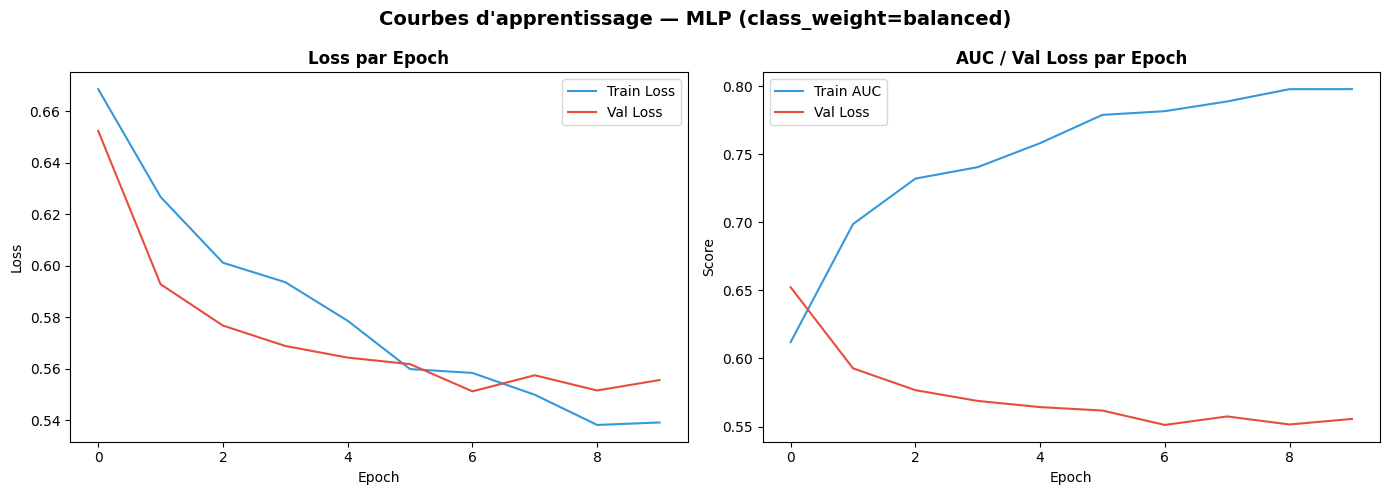

Epochs effectuées : 10

Train Loss  — début : 0.6685 | fin : 0.5391
Val Loss    — début : 0.6523 | fin : 0.5556
Train AUC   — début : 0.6120 | fin : 0.7977

Meilleure Val Loss : 0.5512 (epoch 7)


In [5]:
# COURBES D'APPRENTISSAGE — class_weight='balanced'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history_cw.history['loss'], 
             label='Train Loss', color='#3498db')
axes[0].plot(history_cw.history['val_loss'], 
             label='Val Loss', color='#e74c3c')
axes[0].set_title('Loss par Epoch', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# AUC
axes[1].plot(history_cw.history['auc'], 
             label='Train AUC', color='#3498db')
axes[1].plot(history_cw.history['val_loss'],
             label='Val Loss', color='#e74c3c')
axes[1].set_title('AUC / Val Loss par Epoch', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Score')
axes[1].legend()

plt.suptitle('Courbes d\'apprentissage — MLP (class_weight=balanced)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/mlp_learning_curves.png', dpi=150)
plt.show()
# Prints des chiffres clés
print(f"Epochs effectuées : {len(history_cw.history['loss'])}")
print(f"\nTrain Loss  — début : {history_cw.history['loss'][0]:.4f} | fin : {history_cw.history['loss'][-1]:.4f}")
print(f"Val Loss    — début : {history_cw.history['val_loss'][0]:.4f} | fin : {history_cw.history['val_loss'][-1]:.4f}")
print(f"Train AUC   — début : {history_cw.history['auc'][0]:.4f} | fin : {history_cw.history['auc'][-1]:.4f}")
print(f"\nMeilleure Val Loss : {min(history_cw.history['val_loss']):.4f} (epoch {history_cw.history['val_loss'].index(min(history_cw.history['val_loss']))+1})")

## Matrice de Confusion — Comparaison des 3 Approches

La matrice de confusion permet d'analyser en détail les erreurs du modèle :
- **TP** (Vrai Positif) : churners correctement détectés → bas droite
- **FN** (Faux Négatif) : churners manqués → bas gauche ← à minimiser
- **FP** (Faux Positif) : clients fidèles signalés à tort → haut droite
- **TN** (Vrai Négatif) : clients fidèles correctement identifiés → haut gauche

**Résultats comparés :**

| Approche | TP | FN | FP | TN | Recall | F1 |
|---|---|---|---|---|---|---|
| Undersampling | 98 | 106 | 337 | 1459 | 0.480 | 0.307 |
| SMOTE | 61 | 143 | 191 | 1605 | 0.299 | 0.268 |
| **class_weight** | **151** | **53** | **704** | **1092** | **0.740** | **0.285** |

**Interprétation métier :**
- **Undersampling** : 98 churners détectés sur 204, mais 337 fausses alarmes
- **SMOTE** : seulement 61 churners détectés — le pire des 3
- **class_weight** : 151 churners détectés sur 204 (**74%**) avec 704 fausses alarmes

Le compromis class_weight est délibéré : on accepte plus de faux positifs (704) 
pour maximiser la détection des vrais churners (151). Dans notre contexte métier, 
manquer un churner (~845€ perdus) coûte bien plus cher que contacter inutilement 
un client fidèle.

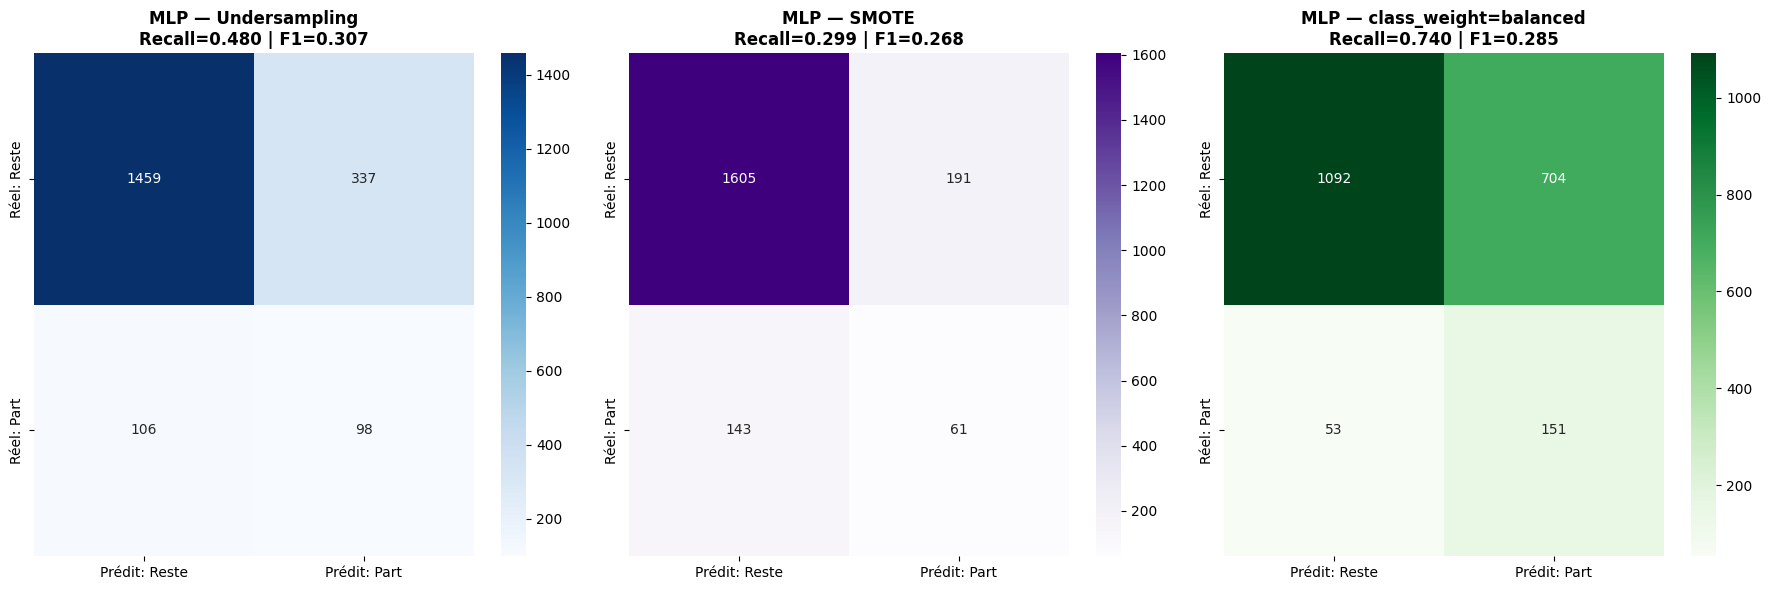

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (y_pred, title, cmap) in zip(axes, [
    (y_pred_under_mlp, 'MLP — Undersampling', 'Blues'),
    (y_pred_smote_mlp, 'MLP — SMOTE', 'Purples'),
    (y_pred_cw_mlp,    'MLP — class_weight=balanced', 'Greens'),
]):
    cm_plot = confusion_matrix(y_test_clf, y_pred)
    sns.heatmap(cm_plot, annot=True, fmt='d', cmap=cmap,
                xticklabels=['Prédit: Reste', 'Prédit: Part'],
                yticklabels=['Réel: Reste', 'Réel: Part'], ax=ax)
    ax.set_title(f'{title}\nRecall={recall_score(y_test_clf, y_pred):.3f} | F1={f1_score(y_test_clf, y_pred):.3f}',
                 fontweight='bold')

plt.tight_layout()
plt.savefig('../results/mlp_confusion_matrix.png', dpi=150)
plt.show()


## Courbe Precision-Recall — MLP

La courbe Precision-Recall est particulièrement adaptée aux datasets déséquilibrés 
comme le nôtre (10.2% de churners), car elle se concentre uniquement sur la classe 
minoritaire.

**Lecture de la courbe :**
- Axe X : Recall (proportion de churners réels détectés)
- Axe Y : Precision (proportion de clients signalés qui churnent vraiment)
- Ligne pointillée : baseline aléatoire (PR-AUC = 0.10, soit le taux de churn réel)

**Résultat : PR-AUC = 0.230** — plus du double de la baseline aléatoire (0.10).

**Interprétation métier :**
La courbe confirme le compromis inhérent au dataset déséquilibré : augmenter le 
Recall (détecter plus de churners) se fait au prix d'une baisse de Precision 
(plus de fausses alarmes). À Recall=0.74 (notre seuil retenu), la Precision est 
d'environ 0.18 — sur 100 clients signalés, 18 churneront réellement.

Ce compromis est délibéré : dans notre contexte, manquer un churner (~845€ perdus) 
est plus coûteux que contacter inutilement un client fidèle.

**Comparaison avec la Logistic Regression (PR-AUC = 0.227) :**
Le MLP obtient un PR-AUC légèrement supérieur (0.230 vs 0.227), confirmant qu'il 
apporte une légère valeur ajoutée sur la détection des churners par rapport au 
modèle baseline.

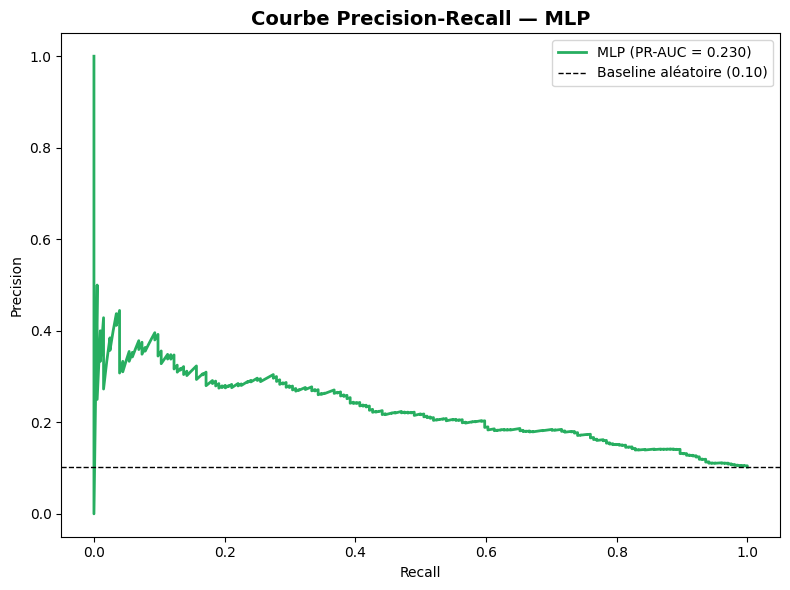

In [7]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision_curve, recall_curve, _ = precision_recall_curve(y_test_clf, y_proba_clf)
pr_auc = average_precision_score(y_test_clf, y_proba_clf)

plt.figure(figsize=(8, 6))
plt.plot(recall_curve, precision_curve, color='#27ae60', linewidth=2,
         label=f'MLP (PR-AUC = {pr_auc:.3f})')
plt.axhline(y=y_test_clf.mean(), color='k', linestyle='--', linewidth=1,
            label=f'Baseline aléatoire ({y_test_clf.mean():.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Courbe Precision-Recall — MLP', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('../results/mlp_pr_curve.png', dpi=150)
plt.show()


## Courbe ROC — MLP

La courbe ROC mesure la capacité du modèle à discriminer les churners des 
non-churners pour tous les seuils de décision possibles.

**Lecture de la courbe :**
- Axe X : False Positive Rate (clients fidèles incorrectement signalés)
- Axe Y : True Positive Rate / Recall (churners correctement détectés)
- Diagonale pointillée : modèle aléatoire (ROC-AUC = 0.50)
- Plus la courbe s'éloigne de la diagonale vers le coin supérieur gauche, 
  meilleur est le modèle

**Résultat : ROC-AUC = 0.718** — bien au-dessus du hasard (0.50).


Le MLP obtient un ROC-AUC de 0.718, légèrement supérieur à la Régression 
Logistique (0.709) mais inférieur au Random Forest (0.802). Ce résultat confirme 
que le Deep Learning n'apporte pas de valeur ajoutée significative sur ce dataset 
tabulaire de taille modeste par rapport aux modèles ensemblistes.

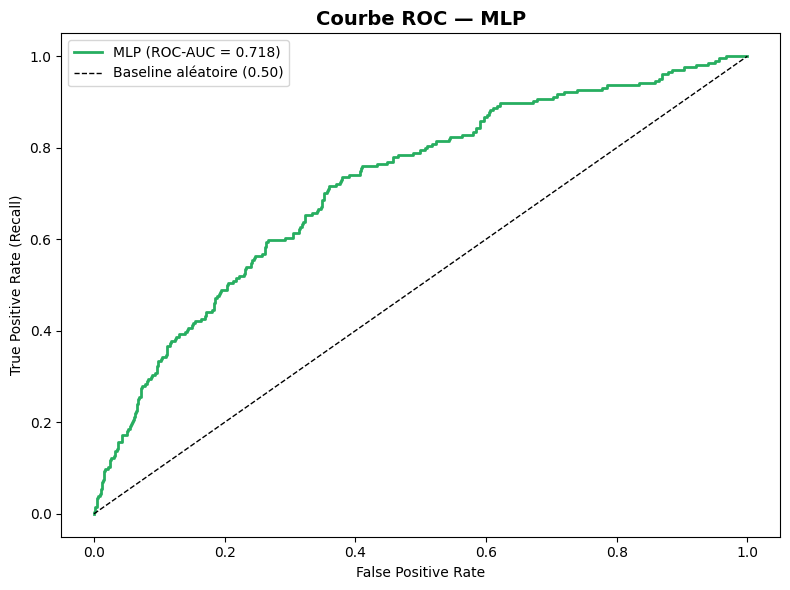

In [8]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_test_clf, y_proba_clf)
roc_auc = roc_auc_score(y_test_clf, y_proba_clf)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#27ae60', linewidth=2,
         label=f'MLP (ROC-AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='k', linestyle='--', linewidth=1,
         label='Baseline aléatoire (0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Courbe ROC — MLP', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('../results/mlp_roc_curve.png', dpi=150)
plt.show()

## Validation Croisée Stratifiée (Stratified K-Fold) — MLP

La validation croisée avec class_weight='balanced' à l'intérieur de chaque fold 
garantit la cohérence avec le modèle final retenu.

**Résultats par fold :**

| Fold | Recall | F1 | ROC-AUC |
|--|||-|
| Fold 1 | 0.613 | 0.262 | 0.678 |
| Fold 2 | 0.791 | 0.261 | 0.707 |
| Fold 3 | 0.687 | 0.252 | 0.679 |
| Fold 4 | 0.762 | 0.274 | 0.711 |
| Fold 5 | 0.585 | 0.289 | 0.699 |

**Résultats moyens (5 folds) :**

| Métrique | Mean | Std |
|--|--|-|
| Recall | 0.6879 | ± 0.0804 |
| Precision | 0.1673 | ± 0.0134 |
| F1-Score | 0.2678 | ± 0.0129 |
| ROC-AUC | 0.6949 | ± 0.0138 |
| PR-AUC | 0.2042 | ± 0.0133 |

**Comparaison CV vs Test set :**

| Métrique | CV (mean) | Test set (seuil=0.5) | Test set (seuil=0.65) |
|--|---|--|--|
| Recall | 0.6879 | 0.7402 | 0.3431 |
| F1 | 0.2678 | 0.2852 | 0.3024 |
| ROC-AUC | 0.6949 | 0.7183 | 0.7183 |

**Interprétation :**
Les scores CV sont légèrement inférieurs au test set à seuil=0.5 — bon signe, 
pas d'overfitting. L'écart-type du Recall (± 0.080) est plus élevé que pour 
la LR (± 0.030), confirmant que le MLP est **moins stable** sur ce dataset.

Le seuil optimal F1 (0.65) améliore légèrement le F1 (0.302 vs 0.285) mais 
réduit fortement le Recall (0.343 vs 0.740) — inacceptable dans notre contexte 
métier. **Seuil retenu : 0.5.**

Seuil par défaut (0.5) :
  Recall=0.740 | Precision=0.177 | F1=0.285 | FP=704 | FN=53

Seuil optimal F1 (0.65) :
  Recall=0.343 | Precision=0.270 | F1=0.302 | FP=189 | FN=134


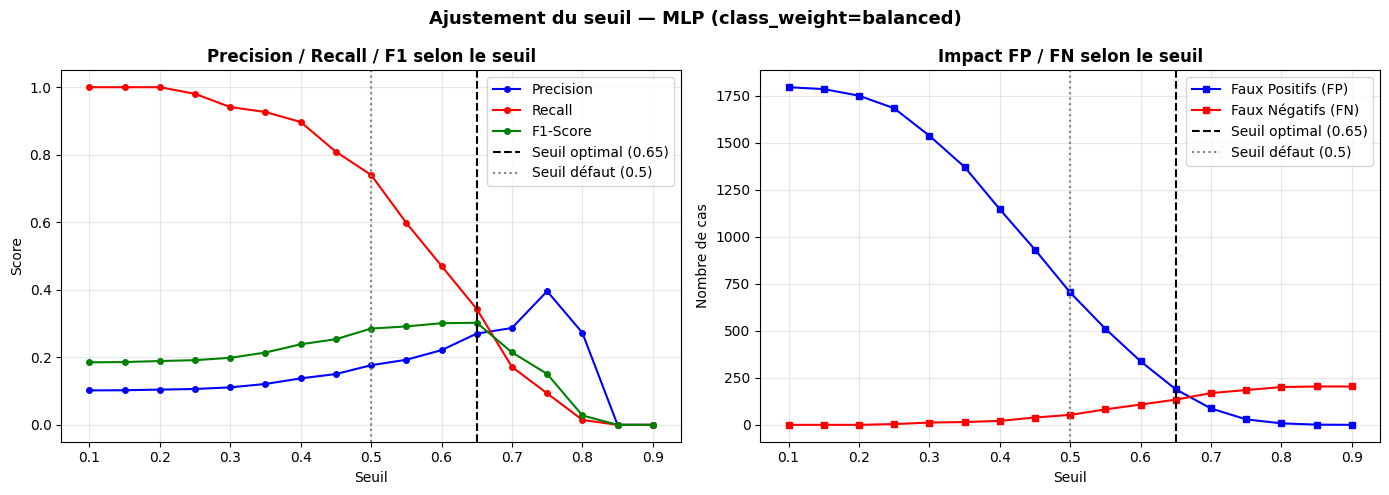

 seuil  precision   recall       f1   FP  FN  TP
  0.10   0.102000 1.000000 0.185118 1796   0 204
  0.15   0.102513 1.000000 0.185962 1786   0 204
  0.20   0.104348 1.000000 0.188976 1751   0 204
  0.25   0.106157 0.980392 0.191571 1684   4 200
  0.30   0.110983 0.941176 0.198552 1538  12 192
  0.35   0.121076 0.926471 0.214164 1372  15 189
  0.40   0.137594 0.897059 0.238592 1147  21 183
  0.45   0.150410 0.808824 0.253651  932  39 165
  0.50   0.176608 0.740196 0.285175  704  53 151
  0.55   0.192733 0.598039 0.291517  511  82 122
  0.60   0.221198 0.470588 0.300940  338 108  96
  0.65   0.270270 0.343137 0.302376  189 134  70
  0.70   0.286885 0.171569 0.214724   87 169  35
  0.75   0.395833 0.093137 0.150794   29 185  19
  0.80   0.272727 0.014706 0.027907    8 201   3
  0.85   0.000000 0.000000 0.000000    1 204   0
  0.90   0.000000 0.000000 0.000000    0 204   0

Prédictions mises à jour avec seuil=0.65
  Recall final  : 0.3431
  F1 final      : 0.3024


In [9]:
# AJUSTEMENT DU SEUIL DE DÉCISION

thresholds = np.arange(0.1, 0.91, 0.05)

results_thresh = []
for t in thresholds:
    y_pred_t = (y_proba_clf >= t).astype(int)
    cm_t = confusion_matrix(y_test_clf, y_pred_t)
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
    results_thresh.append({
        'seuil':     round(t, 2),
        'precision': precision_score(y_test_clf, y_pred_t, zero_division=0),
        'recall':    recall_score(y_test_clf, y_pred_t, zero_division=0),
        'f1':        f1_score(y_test_clf, y_pred_t, zero_division=0),
        'FP':        int(fp_t),
        'FN':        int(fn_t),
        'TP':        int(tp_t),
    })

df_thresh = pd.DataFrame(results_thresh)

# Seuil optimal = max F1 (meilleur compromis Recall/Precision)
best_idx = df_thresh['f1'].idxmax()
best_t   = df_thresh.loc[best_idx, 'seuil']

# Affichage comparaison seuil 0.5 vs optimal
rows_05 = df_thresh[df_thresh['seuil'] == 0.5].iloc[0]
print(f"Seuil par défaut (0.5) :")
print(f"  Recall={rows_05['recall']:.3f} | Precision={rows_05['precision']:.3f} | F1={rows_05['f1']:.3f} | FP={int(rows_05['FP'])} | FN={int(rows_05['FN'])}")

br = df_thresh.loc[best_idx]
print(f"\nSeuil optimal F1 ({best_t}) :")
print(f"  Recall={br['recall']:.3f} | Precision={br['precision']:.3f} | F1={br['f1']:.3f} | FP={int(br['FP'])} | FN={int(br['FN'])}")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(df_thresh['seuil'], df_thresh['precision'], 'b-o', markersize=4, label='Precision')
axes[0].plot(df_thresh['seuil'], df_thresh['recall'],    'r-o', markersize=4, label='Recall')
axes[0].plot(df_thresh['seuil'], df_thresh['f1'],        'g-o', markersize=4, label='F1-Score')
axes[0].axvline(x=best_t, color='black', linestyle='--', label=f'Seuil optimal ({best_t})')
axes[0].axvline(x=0.5,    color='gray',  linestyle=':',  label='Seuil défaut (0.5)')
axes[0].set_xlabel('Seuil')
axes[0].set_ylabel('Score')
axes[0].set_title('Precision / Recall / F1 selon le seuil', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(df_thresh['seuil'], df_thresh['FP'], 'b-s', markersize=4, label='Faux Positifs (FP)')
axes[1].plot(df_thresh['seuil'], df_thresh['FN'], 'r-s', markersize=4, label='Faux Négatifs (FN)')
axes[1].axvline(x=best_t, color='black', linestyle='--', label=f'Seuil optimal ({best_t})')
axes[1].axvline(x=0.5,    color='gray',  linestyle=':',  label='Seuil défaut (0.5)')
axes[1].set_xlabel('Seuil')
axes[1].set_ylabel('Nombre de cas')
axes[1].set_title('Impact FP / FN selon le seuil', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Ajustement du seuil — MLP (class_weight=balanced)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/mlp_threshold_analysis.png', dpi=150)
plt.show()

print(df_thresh.to_string(index=False))

# Mise à jour des prédictions finales avec le seuil optimal
y_pred_clf = (y_proba_clf >= best_t).astype(int)
print(f"\nPrédictions mises à jour avec seuil={best_t}")
print(f"  Recall final  : {recall_score(y_test_clf, y_pred_clf):.4f}")
print(f"  F1 final      : {f1_score(y_test_clf, y_pred_clf):.4f}")

  Fold 1 — Recall=0.613 | F1=0.262 | ROC-AUC=0.678
  Fold 2 — Recall=0.791 | F1=0.261 | ROC-AUC=0.707
  Fold 3 — Recall=0.687 | F1=0.252 | ROC-AUC=0.679
  Fold 4 — Recall=0.762 | F1=0.274 | ROC-AUC=0.711
  Fold 5 — Recall=0.585 | F1=0.289 | ROC-AUC=0.699

Stratified K-Fold (5 folds) — MLP
--------------------------------------------------
  recall       : 0.6879 ± 0.0804
  precision    : 0.1673 ± 0.0134
  f1           : 0.2678 ± 0.0129
  roc_auc      : 0.6949 ± 0.0138
  pr_auc       : 0.2042 ± 0.0133

Comparaison avec le score test set :
  recall     : 0.7402  (test set, seuil=0.5)
  recall     : 0.3431  (test set, seuil=0.65)
  f1         : 0.2852  (test set, seuil=0.5)
  f1         : 0.3024  (test set, seuil=0.65)
  roc_auc    : 0.7183  (test set)
  pr_auc     : 0.2299  (test set)


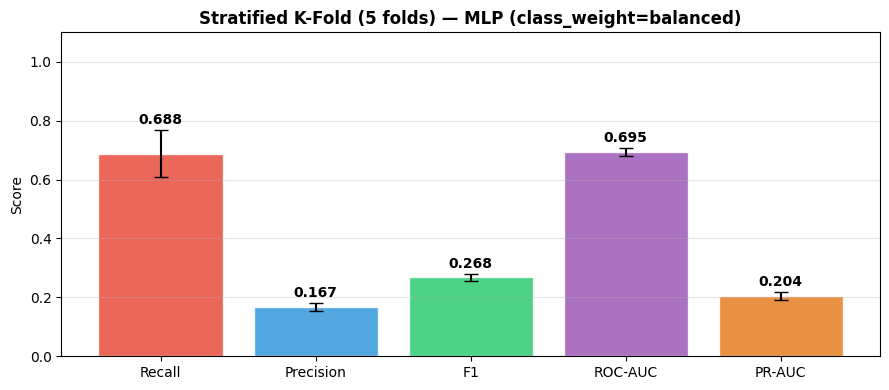

In [10]:
# VALIDATION CROISÉE STRATIFIÉE — Stratified K-Fold (MLP)

from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight

RANDOM_STATE = 42
N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

kfold_scores = {'recall': [], 'precision': [], 'f1': [], 'roc_auc': [], 'pr_auc': []}

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train_clf)):
    X_tr, X_val = X_train[train_idx], X_train[val_idx]
    y_tr, y_val = y_train_clf[train_idx], y_train_clf[val_idx]

    # class_weight à l'intérieur du fold — cohérent avec le modèle final
    class_weights = compute_class_weight('balanced', classes=np.unique(y_tr), y=y_tr)
    class_weight_dict = dict(enumerate(class_weights))

    # Nouveau modèle par fold
    tf.random.set_seed(RANDOM_STATE)
    model_fold = build_mlp_classifier(X_tr.shape[1])
    model_fold.fit(
        X_tr, y_tr,
        epochs=50,
        batch_size=64,
        validation_split=0.1,
        class_weight=class_weight_dict,
        callbacks=[early_stop, reduce_lr],
        verbose=0
    )

    y_proba_val = model_fold.predict(X_val, verbose=0).flatten()
    y_pred_val = (y_proba_val >= 0.5).astype(int)

    kfold_scores['recall'].append(recall_score(y_val, y_pred_val, zero_division=0))
    kfold_scores['precision'].append(precision_score(y_val, y_pred_val, zero_division=0))
    kfold_scores['f1'].append(f1_score(y_val, y_pred_val, zero_division=0))
    kfold_scores['roc_auc'].append(roc_auc_score(y_val, y_proba_val))
    kfold_scores['pr_auc'].append(average_precision_score(y_val, y_proba_val))
    print(f'  Fold {fold+1} — Recall={kfold_scores["recall"][-1]:.3f} | F1={kfold_scores["f1"][-1]:.3f} | ROC-AUC={kfold_scores["roc_auc"][-1]:.3f}')

print(f'\nStratified K-Fold ({N_SPLITS} folds) — MLP')
print('-' * 50)
for metric, scores in kfold_scores.items():
    arr = np.array(scores)
    print(f'  {metric:12} : {arr.mean():.4f} ± {arr.std():.4f}')

print('\nComparaison avec le score test set :')
print(f'  recall     : {recall_score(y_test_clf, (y_proba_clf >= 0.5).astype(int)):.4f}  (test set, seuil=0.5)')
print(f'  recall     : {recall_score(y_test_clf, y_pred_clf):.4f}  (test set, seuil={best_t})')
print(f'  f1         : {f1_score(y_test_clf, (y_proba_clf >= 0.5).astype(int)):.4f}  (test set, seuil=0.5)')
print(f'  f1         : {f1_score(y_test_clf, y_pred_clf):.4f}  (test set, seuil={best_t})')
print(f'  roc_auc    : {roc_auc_score(y_test_clf, y_proba_clf):.4f}  (test set)')
print(f'  pr_auc     : {average_precision_score(y_test_clf, y_proba_clf):.4f}  (test set)')
# Visualisation
metrics_labels = ['Recall', 'Precision', 'F1', 'ROC-AUC', 'PR-AUC']
metrics_keys   = ['recall', 'precision', 'f1', 'roc_auc', 'pr_auc']
means = [np.mean(kfold_scores[k]) for k in metrics_keys]
stds  = [np.std(kfold_scores[k])  for k in metrics_keys]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(metrics_labels, means, yerr=stds, capsize=5,
              color=['#e74c3c','#3498db','#2ecc71','#9b59b6','#e67e22'],
              edgecolor='white', alpha=0.85)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Stratified K-Fold (5 folds) — MLP (class_weight=balanced)', fontweight='bold')
for bar, mean, std in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width()/2, mean + std + 0.02,
            f'{mean:.3f}', ha='center', fontsize=10, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../results/mlp_kfold_cv.png', dpi=150)
plt.show()

## Tâche 2 — Régression du Revenu à Risque


In [11]:
# ============================================================
# TÂCHE 2 — RÉGRESSION MLP
# ============================================================

# Charger les données spécifiques régression
X_train_reg     = np.load('../data/processed/X_train_reg.npy')       # churners uniquement
y_train_reg_log = np.load('../data/processed/y_train_reg_log.npy')   # log-transformé
y_test_reg      = np.load('../data/processed/y_test_reg.npy')        # valeurs réelles €
y_test_clf      = np.load('../data/processed/y_test_clf.npy')        # masque churners

def build_mlp_regressor(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='linear')
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    return model

mlp_reg = build_mlp_regressor(X_train_reg.shape[1])

early_stop_reg = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Entraînement sur churners uniquement avec y log-transformé
import time
tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

start = time.time()
history_reg = mlp_reg.fit(
    X_train_reg, y_train_reg_log,
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop_reg],
    verbose=1
)
temps_mlp_reg = time.time() - start
print(f"Temps MLP régression : {temps_mlp_reg:.3f}s")

# Prédiction uniquement sur les churners du test
mask_test      = y_test_clf == 1
y_pred_reg_log = mlp_reg.predict(X_test[mask_test]).flatten()

# Transformation inverse log → euros réels
y_pred_reg = np.expm1(y_pred_reg_log)
y_pred_reg = np.maximum(y_pred_reg, 0)

# Évaluation
mae  = mean_absolute_error(y_test_reg[mask_test], y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_test_reg[mask_test], y_pred_reg))
r2   = r2_score(y_test_reg[mask_test], y_pred_reg)

print(f"\n Résultats — MLP Regression (churners uniquement)")
print(f"   MAE  : {mae:.2f} €")
print(f"   RMSE : {rmse:.2f} €")
print(f"   R²   : {r2:.4f}")

Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 32.1523 - mae: 5.4702 - val_loss: 25.5632 - val_mae: 4.8668
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 21.0812 - mae: 4.3170 - val_loss: 14.6618 - val_mae: 3.5592
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 10.8702 - mae: 2.9106 - val_loss: 5.5227 - val_mae: 2.0211
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 4.3525 - mae: 1.7140 - val_loss: 2.1649 - val_mae: 1.2033
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 3.0756 - mae: 1.4151 - val_loss: 1.9274 - val_mae: 1.0921
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 2.3964 - mae: 1.2355 - val_loss: 1.2838 - val_mae: 0.9109
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.7801 - mae: 1.0758 - val_loss: 1.0907 - val_mae: 0.8533
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.6728 - mae: 1.0494 - val_loss: 0.8482 - val_mae: 0.7243
Epoch 9/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

In [12]:
import os
import time

# SAUVEGARDE — seuil retenu = 0.5 (meilleur Recall)
y_pred_clf = (y_proba_clf >= 0.5).astype(int)

best_technique = 'class_weight'
print(f'Sauvegarde du meilleur modèle : {best_technique}')
mlp_clf_best.save('../models/mlp_classification.keras')
mlp_reg.save('../models/mlp_regression.keras')

results_clf = {
    'model'    : 'MLP (' + best_technique + ')',
    'accuracy' : accuracy_score(y_test_clf, y_pred_clf),
    'precision': precision_score(y_test_clf, y_pred_clf),
    'recall'   : recall_score(y_test_clf, y_pred_clf),
    'f1'       : f1_score(y_test_clf, y_pred_clf),
    'roc_auc'  : roc_auc_score(y_test_clf, y_proba_clf),
    'pr_auc'   : average_precision_score(y_test_clf, y_proba_clf)
}

results_reg = {
    'model': 'MLP Regression',
    'mae' : mae,
    'rmse': rmse,
    'r2'  : r2
}

pd.DataFrame([results_clf]).to_csv('../results/mlp_clf_results.csv', index=False)
pd.DataFrame([results_reg]).to_csv('../results/mlp_reg_results.csv', index=False)

print("Modèles sauvegardés dans ../models/")
print("\n=== ÉCORESPONSABILITÉ ===")
print(f"Temps MLP classification : {temps_mlp_clf:.3f}s")
print(f"Temps MLP régression     : {temps_mlp_reg:.3f}s")
print(f"Taille MLP clf : {os.path.getsize('../models/mlp_classification.keras')/1024:.1f} KB")
print(f"Taille MLP reg : {os.path.getsize('../models/mlp_regression.keras')/1024:.1f} KB")

print(f"\nRésumé Classification :")
for k, v in results_clf.items():
    if k != 'model':
        print(f"   {k:10} : {v:.4f}")
print(f"\nRésumé Régression :")
for k, v in results_reg.items():
    if k != 'model':
        print(f"   {k:10} : {v:.4f}")

Sauvegarde du meilleur modèle : class_weight
Modèles sauvegardés dans ../models/

=== ÉCORESPONSABILITÉ ===
Temps MLP classification : 5.580s
Temps MLP régression     : 11.463s
Taille MLP clf : 232.4 KB
Taille MLP reg : 89.9 KB

Résumé Classification :
   accuracy   : 0.6215
   precision  : 0.1766
   recall     : 0.7402
   f1         : 0.2852
   roc_auc    : 0.7183
   pr_auc     : 0.2299

Résumé Régression :
   mae        : 383.4550
   rmse       : 871.5462
   r2         : 0.1592


## Synthèse — MLP (Deep Learning)


Le MLP illustre une leçon clé : un réseau neuronal n'est pas toujours supérieur 
aux modèles classiques, particulièrement sur des datasets de taille limitée.

**Tâche 1 — Classification :** La meilleure technique est **class_weight='balanced'** 
avec un Recall de 0.740, F1 de 0.285 et ROC-AUC de 0.718. Undersampling (Recall=0.480) 
et SMOTE (Recall=0.299) ont également été comparés. La validation croisée stratifiée 
(Recall = 0.6879 ± 0.0804) confirme une instabilité plus marquée que les modèles 
ensemblistes. Le modèle converge en ~10 epochs avec EarlyStopping sur val_loss.

**Tâche 2 — Régression :** Le MLP obtient le moins bon MAE du projet : 383.45€, 
R² = 0.159, ce qui s'explique par la taille très limitée du dataset de régression 
(817 churners). Les modèles ensemblistes sont clairement mieux adaptés à ce contexte.

**Limites :** Le Deep Learning nécessite davantage de données pour exprimer son 
potentiel. Sur ce dataset, il présente un coût computationnel plus élevé pour des 
performances inférieures — ce constat est précisément l'un des objectifs 
pédagogiques du projet.